## **4. Desarrollo y evaluación de modelos de recomendación**

**Objetivo:** entrenar, evaluar y comparar ocho modelos de recomendación musical basados en contenido para determinar cuál ofrece la mayor cohesión acústica en sus sugerencias.

**Pasos clave:**
1. Imports y carga de datos
2. Preparación del espacio de características
3. Reducción de dimensionalidad (PCA)
4. Funciones de evaluación
5. Modelos sin PCA: similitud del coseno, KNN euclidiana, KNN Manhattan y K-Means sobre las 24 dimensiones originales.
6. Modelos con PCA: los mismos cuatro modelos sobre el espacio reducido.
7. Comparativa final y elección del mejor modelo


> **Recordatorio metodológico:** en ausencia de un *ground truth* de relevancia (historial de escucha o valoraciones explícitas de usuario), la evaluación se apoya en **métricas de cohesión interna**, tal como se justifica en el marco teórico de la memoria. Las métricas empleadas son:
> - **Distancia media intra-vecindario** *(cohesión):* distancia media entre la canción de entrada y sus 5 recomendaciones. Cuanto menor, mayor similitud acústica.
> - **Diversidad intra-lista** *(beyond-accuracy):* distancia media entre las propias 5 recomendaciones entre sí. Cuanto mayor, más variadas son las sugerencias.
>
> Un buen modelo debe equilibrar ambas: alta cohesión (recomendaciones cercanas a la entrada) y diversidad razonable (no recomendar cinco canciones casi idénticas).


### **4.1 Imports y carga de datos**

Importamos las herramientas de `scikit-learn` que utilizaremos a lo largo de todo el análisis y cargaremos el dataset procesado (`dataset_procesado.csv`).

In [1]:
# Librerías estándar
import warnings
warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

# Scikit-learn 
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances, manhattan_distances

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

# Carpeta de salida para figuras 
os.makedirs('figuras/Modelos', exist_ok=True)

#  Carga del dataset procesado
df = pd.read_csv('data/dataset_procesado.csv')
print(f"Dataset cargado: {df.shape[0]:,} canciones | {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 174,582 canciones | 28 columnas


,track_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,...,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Major,mode_Minor
0,0BRjO6ga9RKCKjfDqeFgWV,Henri Salvador,C'est beau de faire un Show,0,0.613454,0.356223,0.121687,0.910909,0.0,0.339614,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0BjC1NfoEOOusryehmNudP,Martin & les fées,Perdu d'avance (par Gad Elmaleh),1,0.246988,0.571888,0.188355,0.737732,0.0,0.142710,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0CoSDzoNIKCRs124s9uTVy,Joseph Williams,Don't Let Me Be Lonely Tonight,3,0.955823,0.650215,0.246065,0.131113,0.0,0.094241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### **4.2 Preparación del espacio de características**

Antes de entrenar ningún modelo, es necesario separar el DataFrame en dos estructuras con roles distintos:

- **Metadatos** (`df_metadata`): `track_id`, `artist_name`, `track_name` y `popularity`. Se usan para mostrar resultados al usuario, pero **no participan en el cálculo de distancias**.
- **Matriz de características** (`X`): las 24 dimensiones sobre las que operarán los algoritmos (10 variables numéricas normalizadas + 14 columnas binarias del One-Hot Encoding).

Adicionalmente, se define una **muestra aleatoria de 1.000 canciones** con semilla fija (`RANDOM_STATE = 42`) que actuará como conjunto de evaluación consistente para todos los modelos. Evaluar sobre una muestra representativa en lugar del catálogo completo es la práctica estándar cuando el coste computacional de calcular vecindarios sobre 174.000 instancias hace inviable la comparación directa.


In [2]:
# Separación de metadatos y características
metadata_cols = ['track_id', 'artist_name', 'track_name', 'popularity']
feature_cols = [c for c in df.columns if c not in metadata_cols]

df_metadata = df[metadata_cols].reset_index(drop=True)
X = df[feature_cols].values

print(f"Metadatos: {df_metadata.shape}")
print(f"Matriz de features: {X.shape}")
print(f"\nCaracterísticas del modelo ({len(feature_cols)}):")
print(feature_cols)

Metadatos: (174582, 4)
Matriz de features: (174582, 24)

Características del modelo (24):
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'key_A', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Major', 'mode_Minor']


In [3]:
# Muestra de evaluación (1.000 canciones, semilla fija)
N_EVAL = 1000
np.random.seed(RANDOM_STATE)
eval_idx = np.random.choice(len(X), size=N_EVAL, replace=False)
X_eval = X[eval_idx]

print(f"Muestra de evaluación: {X_eval.shape[0]:,} canciones seleccionadas aleatoriamente.")

Muestra de evaluación: 1,000 canciones seleccionadas aleatoriamente.


### **4.3 Reducción de dimensionalidad (PCA)**

El Análisis de Componentes Principales (PCA) transforma el espacio original de 24 dimensiones en un subespacio de menor dimensión que retiene la mayor parte de la varianza informativa del catálogo. Su aplicación persigue dos objetivos en este proyecto:

1. **Mitigar la multicolinealidad** detectada en el EDA (especialmente entre `energy` y `loudness`, r = +0.82), evitando que variables redundantes inflen artificialmente su peso en el cálculo de distancias.
2. **Reducir el coste computacional** de los algoritmos de vecindario (KNN), que escalan con el número de dimensiones.

El criterio de retención adoptado es el **90% de la varianza explicada**: se selecciona el número mínimo de componentes principales necesario para capturar al menos ese umbral de información. La gráfica de varianza acumulada permite visualizar cuántos componentes resultan suficientes y justifica la decisión de forma objetiva.

> **Nota:** el PCA se ajusta (`fit`) sobre la **totalidad del catálogo** (`X`), no solo sobre la muestra de evaluación. De este modo, los componentes principales reflejan la estructura global del espacio acústico. La transformación (`transform`) se aplica después tanto a `X` completo como a `X_eval`, garantizando consistencia.

Componentes necesarios para retener el 90% de la varianza: 15
Varianza explicada exacta con 15 componentes: 0.9291


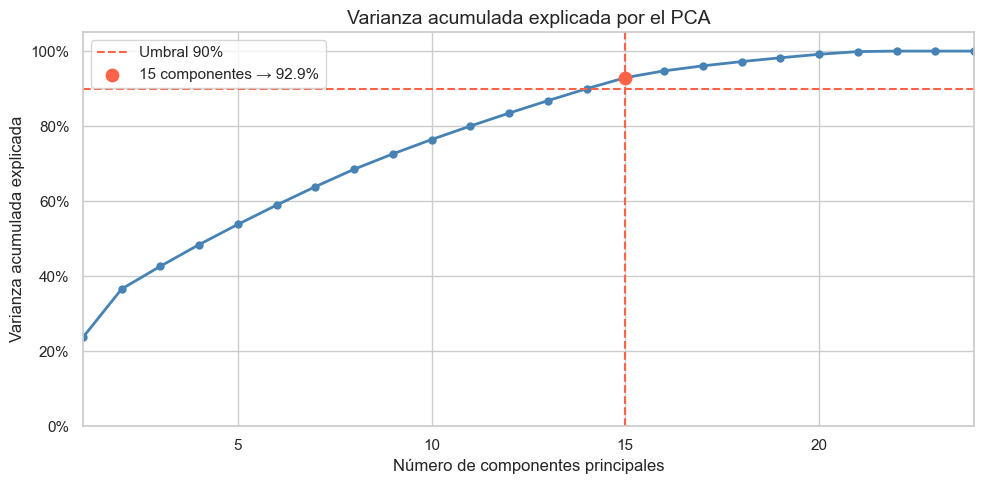

In [4]:
# Ajuste del PCA sobre el catálogo completo
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
n_componentes_90 = np.argmax(varianza_acumulada >= 0.90) + 1

print(f"Componentes necesarios para retener el 90% de la varianza: {n_componentes_90}")
print(f"Varianza explicada exacta con {n_componentes_90} componentes: "
      f"{varianza_acumulada[n_componentes_90 - 1]:.4f}")

# Gráfica de varianza acumulada
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
        marker='o', markersize=5, color='steelblue', linewidth=2)

ax.axhline(y=0.90, color='tomato', linestyle='--', linewidth=1.5, label='Umbral 90%')
ax.axvline(x=n_componentes_90, color='tomato', linestyle='--', linewidth=1.5)
ax.scatter([n_componentes_90], [varianza_acumulada[n_componentes_90 - 1]],
           color='tomato', zorder=5, s=80,
           label=f'{n_componentes_90} componentes → {varianza_acumulada[n_componentes_90-1]:.1%}')

ax.set_xlabel('Número de componentes principales', fontsize=12)
ax.set_ylabel('Varianza acumulada explicada', fontsize=12)
ax.set_title('Varianza acumulada explicada por el PCA', fontsize=14)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=11)
ax.set_xlim(1, len(varianza_acumulada))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('figuras/Modelos/pca_varianza_acumulada.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# PCA final con el número de componentes seleccionado
pca = PCA(n_components=n_componentes_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)             # catálogo completo reducido
X_eval_pca = pca.transform(X[eval_idx])  # muestra de evaluación reducida

print(f"Dimensiones originales: {X.shape}")
print(f"Dimensiones reducidas: {X_pca.shape}")
print(f"Reducción: {X.shape[1]} → {X_pca.shape[1]} dimensiones "
      f"({(1 - X_pca.shape[1]/X.shape[1])*100:.1f}% menos)")

# Exportar el objeto PCA para reutilizarlo en la app
joblib.dump(pca, 'models/modelo_pca.joblib')
print("\nmodelo_pca.joblib exportado correctamente.")

Dimensiones originales: (174582, 24)
Dimensiones reducidas: (174582, 15)
Reducción: 24 → 15 dimensiones (37.5% menos)

modelo_pca.joblib exportado correctamente.


### **4.4 Funciones de evaluación**

Se definen tres funciones reutilizables que se aplicarán de forma idéntica sobre todos los modelos, garantizando que la comparativa sea justa y reproducible.

**`calcular_cohesion(query_vector, recomendaciones, metric)`**
Mide la **distancia media entre la canción de entrada y cada una de sus 5 recomendaciones**. Cuanto menor sea este valor, más acústicamente similares son las sugerencias a la canción original. Es la métrica principal de evaluación.

**`calcular_diversidad(recomendaciones, metric)`**
Mide la **distancia media entre todas las parejas posibles de las 5 recomendaciones entre sí**. Cuanto mayor sea este valor, más variadas son las sugerencias. Es la métrica *beyond-accuracy* complementaria.

**`evaluar_modelo(recomendar_fn, X_eval_sample, metric)`**
Encapsula el bucle completo de evaluación: para cada una de las 1.000 canciones de la muestra, obtiene sus 5 recomendaciones mediante `recomendar_fn`, calcula cohesión y diversidad, y devuelve la media de ambas métricas. Cada modelo definirá su propia `recomendar_fn` y se la pasará como argumento.

Dado que cada modelo usa una métrica de distancia distinta (coseno, euclidiana o Manhattan), y que sus rangos numéricos son incomparables entre sí, los valores brutos no pueden compararse directamente entre modelos de distinta métrica. La normalización y el score ponderado final se calcularán en la sección 4.7, una vez disponibles los resultados de todos los modelos.

In [6]:
from itertools import combinations

def calcular_cohesion(query_vector, recomendaciones, metric='cosine'):
    """
    Distancia media entre la canción de entrada y sus K recomendaciones.
    ----------
    Parámetros:
    query_vector : array (1, n_features) - vector de la canción de entrada.
    recomendaciones: array (K, n_features) - vectores de las K canciones recomendadas.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    float - distancia media intra-vecindario.
    """
    if metric == 'cosine':
        distancias = cosine_distances(query_vector, recomendaciones)[0]
    elif metric == 'euclidean':
        distancias = euclidean_distances(query_vector, recomendaciones)[0]
    else:  # manhattan
        distancias = manhattan_distances(query_vector, recomendaciones)[0]
    return float(np.mean(distancias))

In [7]:
def calcular_diversidad(recomendaciones, metric='cosine'):
    """
    Distancia media entre todas las parejas posibles de las K recomendaciones.
    ----------
    Parámetros:
    recomendaciones: array (K, n_features) - vectores de las K canciones recomendadas.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    float - diversidad intra-lista.
    """
    indices = list(combinations(range(len(recomendaciones)), 2))
    if not indices:
        return 0.0
    pares_a = recomendaciones[[i for i, _ in indices]]
    pares_b = recomendaciones[[j for _, j in indices]]
    if metric == 'cosine':
        distancias = [cosine_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    elif metric == 'euclidean':
        distancias = [euclidean_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    else:  # manhattan
        distancias = [manhattan_distances(pares_a[[k]], pares_b[[k]])[0][0]
                      for k in range(len(indices))]
    return float(np.mean(distancias))

In [8]:
def evaluar_modelo(recomendar_fn, X_eval_sample, metric='cosine'):
    """
    Evalúa un modelo sobre la muestra de evaluación completa.
    Para cada canción de X_eval_sample, obtiene sus 5 recomendaciones
    mediante recomendar_fn y calcula cohesión y diversidad del vecindario.
    Devuelve la media de ambas métricas sobre las N_EVAL canciones.
    ----------
    Parámetros:
    recomendar_fn : callable - recibe array (1, n_features),
                    devuelve array (K, n_features) con las recomendaciones.
    X_eval_sample : array (N_EVAL, n_features) - muestra de canciones de entrada.
    metric : 'cosine' | 'euclidean' | 'manhattan'
    --------
    Devuelve:
    (float, float) - (cohesión_media, diversidad_media)
    """
    cohesiones   = []
    diversidades = []

    for i in range(len(X_eval_sample)):
        query = X_eval_sample[i].reshape(1, -1)
        recomendadas = recomendar_fn(query)  # (K, n_features)
        cohesiones.append(calcular_cohesion(query, recomendadas, metric))
        diversidades.append(calcular_diversidad(recomendadas, metric))

    return float(np.mean(cohesiones)), float(np.mean(diversidades))


print("Funciones de evaluación definidas correctamente:")
print("  · calcular_cohesion → distancia media canción → recomendaciones")
print("  · calcular_diversidad → distancia media entre recomendaciones entre sí")
print("  · evaluar_modelo → bucle completo sobre la muestra de 1.000 canciones")

Funciones de evaluación definidas correctamente:
  · calcular_cohesion → distancia media canción → recomendaciones
  · calcular_diversidad → distancia media entre recomendaciones entre sí
  · evaluar_modelo → bucle completo sobre la muestra de 1.000 canciones


### **4.5 Grupo A - Modelos sin reducción de dimensionalidad**

En este grupo se entrenan y evalúan cuatro modelos operando directamente sobre el espacio vectorial original de **24 dimensiones**. El objetivo es establecer una línea base de rendimiento antes de aplicar PCA, permitiendo cuantificar posteriormente el impacto real de la reducción de dimensionalidad.

Los modelos a comparar son:

|   | Modelo | Métrica de distancia |
|---|--------|----------------------|
| A1 | Similitud del Coseno | Coseno |
| A2 | KNN Euclidiana | Euclidiana |
| A3 | KNN Manhattan | Manhattan |
| A4 | K-Means | Euclidiana |

Cada modelo seguirá el mismo esquema: definición e implementación, entrenamiento y llamada a `evaluar_modelo`. Los resultados parciales se acumularán en el diccionario `resultados` para su uso en la comparativa final de la sección 4.7.

In [9]:
# Diccionario donde se acumularán los resultados de todos los modelos
# Formato: {'nombre_modelo': (cohesion_media, diversidad_media)}
resultados = {}

#### **A1 - Similitud del Coseno**

La similitud del coseno evalúa el **ángulo** entre dos vectores en el espacio de características, ignorando su magnitud. Es la métrica más adecuada para este espacio vectorial por dos motivos: todas las componentes son no negativas (gracias al `MinMaxScaler`), y permite comparar canciones independientemente de la escala absoluta de sus valores.

La implementación sigue un enfoque de **fuerza bruta**: dado un vector de entrada, se calcula su distancia coseno frente a las 174.582 canciones del catálogo completo y se devuelven las 5 más cercanas. No requiere entrenamiento previo.

Un detalle importante: cuando la canción de entrada pertenece al catálogo (como ocurre con todas las canciones de `X_eval`), el modelo se encontrará a sí misma con distancia 0. Por eso se toman los índices `[1:6]` del array ordenado, saltando ese primer resultado.

In [10]:
# A1: Similitud del Coseno
def recomendar_coseno(query, catalogo=X, k=5):
    """
    Devuelve los K vectores del catálogo más cercanos a query según distancia coseno.
    Excluye la propia canción de entrada (distancia 0).
    """
    distancias = cosine_distances(query, catalogo)[0]   # (174582,)
    indices = np.argsort(distancias)[1:k+1]             # saltar índice 0 (ella misma)
    return catalogo[indices]                            # (K, 24)

In [11]:
# Evaluación
print("Evaluando A1 - Similitud del Coseno...")
cohesion_a1, diversidad_a1 = evaluar_modelo(
    recomendar_fn = recomendar_coseno,
    X_eval_sample = X_eval,
    metric = 'cosine'
)

resultados['A1_Coseno'] = (cohesion_a1, diversidad_a1)

print(f"  Cohesión media (↓ mejor): {cohesion_a1:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_a1:.4f}")

Evaluando A1 - Similitud del Coseno...
  Cohesión media (↓ mejor): 0.0047
  Diversidad media (↑ mejor): 0.0069


#### **A2 - KNN Euclidiana**

K-Nearest Neighbors con distancia euclidiana busca los K puntos más cercanos en línea recta en el espacio de 24 dimensiones. A diferencia de la Similitud del Coseno, KNN construye una **estructura de índice** sobre el catálogo durante el entrenamiento (`fit`), lo que evita recalcular todas las distancias desde cero en cada consulta.

Se solicitan `n_neighbors=6` vecinos porque el primero siempre será la propia canción de entrada con distancia 0, y se descarta antes de devolver las 5 recomendaciones finales. El parámetro `algorithm='auto'` permite a scikit-learn seleccionar automáticamente la estructura de búsqueda más eficiente para los datos.

In [12]:
# A2: KNN Euclidiana

# Entrenamiento: construcción de la estructura de índice sobre el catálogo
knn_euclidean = NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='auto')
knn_euclidean.fit(X)
print("Modelo KNN Euclidiana entrenado correctamente.")

Modelo KNN Euclidiana entrenado correctamente.


In [13]:
def recomendar_knn_euclidean(query, k=5):
    """
    Devuelve los K vectores del catálogo más cercanos a query según distancia euclidiana.
    Excluye la propia canción de entrada (primer vecino, distancia 0).
    """
    _, indices = knn_euclidean.kneighbors(query)  # indices: (1, 6)
    indices = indices[0][1:k+1]                   # saltar índice 0 (ella misma)
    return X[indices]                             # (K, 24)


In [14]:
# Evaluación
print("Evaluando A2 - KNN Euclidiana...")
cohesion_a2, diversidad_a2 = evaluar_modelo(
    recomendar_fn = recomendar_knn_euclidean,
    X_eval_sample = X_eval,
    metric = 'euclidean'
)

resultados['A2_KNN_Euclidiana'] = (cohesion_a2, diversidad_a2)

print(f"  Cohesión media (↓ mejor): {cohesion_a2:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_a2:.4f}")

Evaluando A2 - KNN Euclidiana...
  Cohesión media (↓ mejor): 0.1988
  Diversidad media (↑ mejor): 0.2371


#### **A3 - KNN Manhattan**

KNN con distancia Manhattan suma las diferencias absolutas entre cada par de dimensiones, sin elevar al cuadrado. A diferencia de la distancia euclidiana, **todas las dimensiones contribuyen de forma proporcional**, sin penalizar especialmente las diferencias grandes en una sola variable.

Esto puede resultar ventajoso en este espacio vectorial, donde conviven 10 variables numéricas continuas y 14 columnas binarias procedentes del One-Hot Encoding: la euclidiana tiende a inflar el peso de las diferencias en las variables continuas, mientras que Manhattan las trata de forma más equitativa.

In [15]:
# A3: KNN Manhattan

# Entrenamiento: construcción de la estructura de índice sobre el catálogo
knn_manhattan = NearestNeighbors(n_neighbors=6, metric='manhattan', algorithm='auto')
knn_manhattan.fit(X)
print("Modelo KNN Manhattan entrenado correctamente.")

Modelo KNN Manhattan entrenado correctamente.


In [16]:
def recomendar_knn_manhattan(query, k=5):
    """
    Devuelve los K vectores del catálogo más cercanos a query según distancia Manhattan.
    Excluye la propia canción de entrada (primer vecino, distancia 0).
    """
    _, indices = knn_manhattan.kneighbors(query)  # indices: (1, 6)
    indices = indices[0][1:k+1]                   # saltar índice 0 (ella misma)
    return X[indices]                             # (K, 24)


In [17]:
# Evaluación
print("Evaluando A3 - KNN Manhattan...")
cohesion_a3, diversidad_a3 = evaluar_modelo(
    recomendar_fn = recomendar_knn_manhattan,
    X_eval_sample = X_eval,
    metric = 'manhattan'
)

resultados['A3_KNN_Manhattan'] = (cohesion_a3, diversidad_a3)

print(f"  Cohesión media (↓ mejor): {cohesion_a3:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_a3:.4f}")

Evaluando A3 - KNN Manhattan...
  Cohesión media (↓ mejor): 0.4588
  Diversidad media (↑ mejor): 0.5699


#### **A4 - K-Means**

K-Means agrupa las 174.582 canciones en K clústeres durante el entrenamiento. Para recomendar, se identifica el clúster al que pertenece la canción de entrada y se devuelven las 5 canciones de ese clúster **más cercanas a la propia canción de entrada**, garantizando así la máxima cohesión acústica dentro del grupo.

Antes de entrenar el modelo definitivo, es necesario determinar el valor óptimo de K mediante dos métodos complementarios:

- **Método del codo (Elbow):** grafica la inercia (suma de distancias al cuadrado de cada punto a su centroide) para distintos valores de K. Se busca el punto donde la mejora se estabiliza, formando un "codo".
- **Silhouette Score:** mide la cohesión y separación de los clústeres en una escala [-1, 1]. Cuanto mayor, mejor definidos están los grupos. Se calcula sobre una muestra de 5.000 canciones por coste computacional.

Se exploran valores de K entre 10 y 200 en pasos de 10.

In [18]:
# A4: K-Means - Selección de K (Elbow + Silhouette)

K_RANGE = range(10, 201, 10)
inercias = []
silhouettes = []

# Muestra fija para el Silhouette (5.000 canciones)
np.random.seed(RANDOM_STATE)
sil_idx = np.random.choice(len(X), size=5000, replace=False)
X_sil = X[sil_idx]

print("Calculando Elbow y Silhouette para K en [10, 200]...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    km.fit(X)
    inercias.append(km.inertia_)
    labels_sil = km.predict(X_sil)
    silhouettes.append(silhouette_score(X_sil, labels_sil))
    print(f"  K={k:>3} | Inercia: {km.inertia_:,.1f} | Silhouette: {silhouettes[-1]:.4f}")

print("\nCálculo completado.")

Calculando Elbow y Silhouette para K en [10, 200]...
  K= 10 | Inercia: 172,437.8 | Silhouette: 0.2153
  K= 20 | Inercia: 116,427.2 | Silhouette: 0.3480
  K= 30 | Inercia: 86,099.0 | Silhouette: 0.3710
  K= 40 | Inercia: 74,733.7 | Silhouette: 0.3393
  K= 50 | Inercia: 67,105.4 | Silhouette: 0.3265
  K= 60 | Inercia: 57,699.6 | Silhouette: 0.3233
  K= 70 | Inercia: 52,837.6 | Silhouette: 0.3152
  K= 80 | Inercia: 49,783.0 | Silhouette: 0.2959
  K= 90 | Inercia: 46,786.9 | Silhouette: 0.2803
  K=100 | Inercia: 44,470.9 | Silhouette: 0.2640
  K=110 | Inercia: 41,287.3 | Silhouette: 0.2673
  K=120 | Inercia: 39,278.9 | Silhouette: 0.2501
  K=130 | Inercia: 37,607.4 | Silhouette: 0.2375
  K=140 | Inercia: 36,006.3 | Silhouette: 0.2309
  K=150 | Inercia: 34,669.8 | Silhouette: 0.2281
  K=160 | Inercia: 33,551.3 | Silhouette: 0.2208
  K=170 | Inercia: 32,586.6 | Silhouette: 0.2164
  K=180 | Inercia: 31,761.4 | Silhouette: 0.2109
  K=190 | Inercia: 30,959.0 | Silhouette: 0.2124
  K=200 | Iner

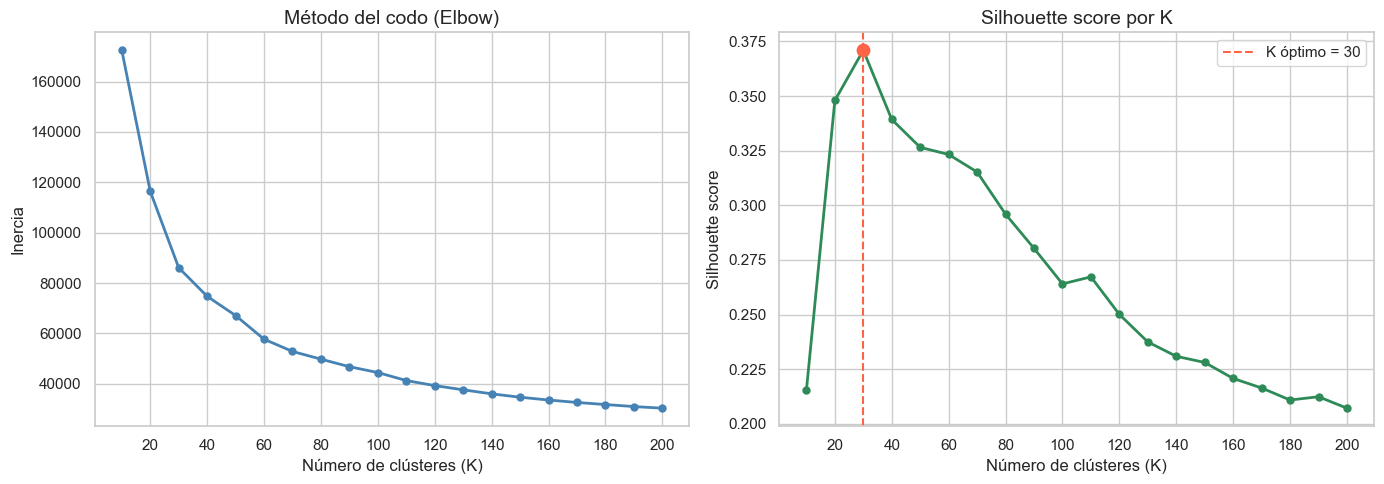

K con mayor Silhouette Score: 30 (0.3710)


In [19]:
# Visualización: Elbow + Silhouette
k_values = list(K_RANGE)
k_best_sil = k_values[np.argmax(silhouettes)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Elbow
axes[0].plot(k_values, inercias, marker='o', markersize=5,
             color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de clústeres (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo (Elbow)', fontsize=14)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(20))

# Gráfica Silhouette
axes[1].plot(k_values, silhouettes, marker='o', markersize=5,
             color='seagreen', linewidth=2)
axes[1].axvline(x=k_best_sil, color='tomato', linestyle='--',
                linewidth=1.5, label=f'K óptimo = {k_best_sil}')
axes[1].scatter([k_best_sil], [max(silhouettes)], color='tomato', zorder=5, s=80)
axes[1].set_xlabel('Número de clústeres (K)', fontsize=12)
axes[1].set_ylabel('Silhouette score', fontsize=12)
axes[1].set_title('Silhouette score por K', fontsize=14)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(20))
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('figuras/Modelos/kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"K con mayor Silhouette Score: {k_best_sil} ({max(silhouettes):.4f})")

Ambos métodos convergen en **K=30**, lo que justifica sólidamente la elección. El Silhouette Score alcanza su máximo en K=30 (0.3710) y desciende de forma continua a partir de ahí, indicando que más clústeres producen grupos menos cohesionados. El método del codo confirma este valor: la curva de inercia muestra su punto de inflexión más notable en torno a K=30, estabilizándose progresivamente a partir de ese punto.

Con K=30, el catálogo queda dividido en grupos de aproximadamente 5.800 canciones, un tamaño que equilibra variedad y similitud acústica dentro de cada clúster.

In [20]:
# Entrenamiento del modelo definitivo
K_OPTIMO = k_best_sil

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init='auto')
kmeans.fit(X)

# Asignar cada canción del catálogo a su clúster
labels = kmeans.labels_  # (174582,) - etiqueta de clúster para cada canción

print(f"K-Means entrenado con K={K_OPTIMO}.")
print(f"Tamaño medio de clúster: {len(X) / K_OPTIMO:,.0f} canciones")

K-Means entrenado con K=30.
Tamaño medio de clúster: 5,819 canciones


In [21]:
def recomendar_kmeans(query, k=5):
    """
    Identifica el clúster de la canción de entrada y devuelve las K canciones
    de ese clúster más cercanas a la propia canción de entrada.
    """
    cluster_id = kmeans.predict(query)[0]
    mask = np.where(labels == cluster_id)[0]               # índices del clúster
    X_cluster = X[mask]                                    # vectores del clúster
    distancias = euclidean_distances(query, X_cluster)[0]  # distancia a la entrada
    top_idx = np.argsort(distancias)[1:k+1]                # saltar ella misma (distancia 0)
    return X_cluster[top_idx]                              # (K, 24)

In [22]:
# Evaluación
print("Evaluando A4 - K-Means...")
cohesion_a4, diversidad_a4 = evaluar_modelo(
    recomendar_fn = recomendar_kmeans,
    X_eval_sample = X_eval,
    metric = 'euclidean'
)

resultados['A4_KMeans'] = (cohesion_a4, diversidad_a4)

print(f"  Cohesión media(↓ mejor): {cohesion_a4:.4f}")
print(f"  Diversidad media(↑ mejor): {diversidad_a4:.4f}")

Evaluando A4 - K-Means...
  Cohesión media(↓ mejor): 0.1995
  Diversidad media(↑ mejor): 0.2374


### **4.6 Grupo B - Modelos con reducción de dimensionalidad (PCA)**

En este grupo se entrenan y evalúan los mismos cuatro modelos del Grupo A, pero operando sobre el espacio reducido por PCA de **`n_componentes_90` dimensiones** en lugar de las 24 originales. El objetivo es cuantificar el impacto real de la reducción de dimensionalidad sobre la calidad de las recomendaciones.

Los modelos utilizan `X_pca` como catálogo y `X_eval_pca` como muestra de evaluación, ambos generados en la sección 4.3. El resto de la metodología es idéntica al Grupo A, garantizando que cualquier diferencia en los resultados sea atribuible exclusivamente al efecto del PCA.

|   | Modelo | Métrica de distancia |
|---|--------|---------------------|
| B1 | PCA + Similitud del Coseno | Coseno |
| B2 | PCA + KNN Euclidiana | Euclidiana |
| B3 | PCA + KNN Manhattan | Manhattan |
| B4 | PCA + K-Means | Euclidiana |

<p></p>

>**Nota:** para K-Means (B4) se reutiliza el mismo valor de K=30 determinado en el Grupo A, ya que la selección de K es una decisión sobre la granularidad del catálogo y no depende del espacio de representación.

#### **B1 - PCA + Similitud del Coseno**

Mismo enfoque que A1, pero operando sobre el espacio reducido por PCA. El cálculo de distancias coseno se realiza entre los vectores comprimidos de `X_pca`, lo que reduce el coste computacional respecto al espacio original de 24 dimensiones.

Al comparar los resultados con A1, podremos determinar si la reducción de dimensionalidad mejora, empeora o mantiene la cohesión de las recomendaciones basadas en similitud del coseno.

In [23]:
# B1: PCA + Similitud del Coseno

def recomendar_coseno_pca(query, catalogo=X_pca, k=5):
    """
    Devuelve los K vectores del catálogo reducido más cercanos a query
    según distancia coseno. Excluye la propia canción de entrada.
    """
    distancias = cosine_distances(query, catalogo)[0]
    indices = np.argsort(distancias)[1:k+1]
    return catalogo[indices]                     # (K, n_componentes_90)


In [24]:
# Evaluación
print("Evaluando B1 - PCA + Similitud del Coseno...")
cohesion_b1, diversidad_b1 = evaluar_modelo(
    recomendar_fn = recomendar_coseno_pca,
    X_eval_sample = X_eval_pca,
    metric = 'cosine'
)

resultados['B1_PCA_Coseno'] = (cohesion_b1, diversidad_b1)

print(f"  Cohesión media (↓ mejor): {cohesion_b1:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_b1:.4f}")

Evaluando B1 - PCA + Similitud del Coseno...
  Cohesión media (↓ mejor): 0.0014
  Diversidad media (↑ mejor): 0.0023


#### **B2 - PCA + KNN Euclidiana**

Mismo enfoque que A2, pero entrenando el índice KNN sobre el espacio reducido `X_pca`. Al operar con menos dimensiones, es más eficiente y el cálculo de distancias euclidianas más preciso, al haber eliminado las dimensiones redundantes detectadas en el EDA.

In [25]:
# B2: PCA + KNN Euclidiana

# Entrenamiento sobre el espacio reducido
knn_euclidean_pca = NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='auto')
knn_euclidean_pca.fit(X_pca)
print("Modelo PCA + KNN Euclidiana entrenado correctamente.")


Modelo PCA + KNN Euclidiana entrenado correctamente.


In [26]:
def recomendar_knn_euclidean_pca(query, k=5):
    """
    Devuelve los K vectores del catálogo reducido más cercanos a query
    según distancia euclidiana. Excluye la propia canción de entrada.
    """
    _, indices = knn_euclidean_pca.kneighbors(query)
    indices = indices[0][1:k+1]
    return X_pca[indices]                        # (K, n_componentes_90)

In [27]:
# Evaluación
print("Evaluando B2 - PCA + KNN Euclidiana...")
cohesion_b2, diversidad_b2 = evaluar_modelo(
    recomendar_fn = recomendar_knn_euclidean_pca,
    X_eval_sample = X_eval_pca,
    metric = 'euclidean'
)

resultados['B2_PCA_KNN_Euclidiana'] = (cohesion_b2, diversidad_b2)

print(f"  Cohesión media (↓ mejor): {cohesion_b2:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_b2:.4f}")

Evaluando B2 - PCA + KNN Euclidiana...
  Cohesión media (↓ mejor): 0.0614
  Diversidad media (↑ mejor): 0.0770


#### **B3 - PCA + KNN Manhattan**

Mismo enfoque que A3, pero entrenando el índice KNN sobre el espacio reducido `X_pca`. Al operar con menos dimensiones, la suma de diferencias absolutas de Manhattan resulta más discriminativa, ya que cada componente principal captura varianza independiente y no redundante.

In [28]:
# B3: PCA + KNN Manhattan

# Entrenamiento sobre el espacio reducido
knn_manhattan_pca = NearestNeighbors(n_neighbors=6, metric='manhattan', algorithm='auto')
knn_manhattan_pca.fit(X_pca)
print("Modelo PCA + KNN Manhattan entrenado correctamente.")


Modelo PCA + KNN Manhattan entrenado correctamente.


In [29]:
def recomendar_knn_manhattan_pca(query, k=5):
    """
    Devuelve los K vectores del catálogo reducido más cercanos a query
    según distancia Manhattan. Excluye la propia canción de entrada.
    """
    _, indices = knn_manhattan_pca.kneighbors(query)
    indices = indices[0][1:k+1]
    return X_pca[indices]                        # (K, n_componentes_90)


In [30]:
# Evaluación
print("Evaluando B3 - PCA + KNN Manhattan...")
cohesion_b3, diversidad_b3 = evaluar_modelo(
    recomendar_fn = recomendar_knn_manhattan_pca,
    X_eval_sample = X_eval_pca,
    metric = 'manhattan'
)

resultados['B3_PCA_KNN_Manhattan'] = (cohesion_b3, diversidad_b3)

print(f"  Cohesión media (↓ mejor): {cohesion_b3:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_b3:.4f}")

Evaluando B3 - PCA + KNN Manhattan...
  Cohesión media (↓ mejor): 0.1615
  Diversidad media (↑ mejor): 0.2082


#### **B4 - PCA + K-Means**

Mismo enfoque que A4, pero el modelo se entrena sobre el espacio reducido `X_pca`. Se reutiliza K=30, determinado en el Grupo A, ya que es una decisión sobre la granularidad del catálogo y no depende del espacio de representación.

Las recomendaciones se obtienen identificando el clúster de la canción de entrada en el espacio PCA y devolviendo las 5 canciones de ese clúster más cercanas a ella.

In [31]:
# B4: PCA + K-Means

# Entrenamiento sobre el espacio reducido
kmeans_pca = KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init='auto')
kmeans_pca.fit(X_pca)

labels_pca = kmeans_pca.labels_  # (174582,)

print(f"PCA + K-Means entrenado con K={K_OPTIMO}.")
print(f"Tamaño medio de clúster: {len(X_pca) / K_OPTIMO:,.0f} canciones")

PCA + K-Means entrenado con K=30.
Tamaño medio de clúster: 5,819 canciones


In [32]:
def recomendar_kmeans_pca(query, k=5):
    """
    Identifica el clúster de la canción de entrada en el espacio reducido
    y devuelve las K canciones de ese clúster más cercanas a la entrada.
    """
    cluster_id = kmeans_pca.predict(query)[0]
    mask = np.where(labels_pca == cluster_id)[0]
    X_cluster = X_pca[mask]
    distancias = euclidean_distances(query, X_cluster)[0]
    top_idx = np.argsort(distancias)[1:k+1]          # saltar ella misma
    return X_cluster[top_idx]                        # (K, n_componentes_90)

In [33]:
# Evaluación
print("Evaluando B4 - PCA + K-Means...")
cohesion_b4, diversidad_b4 = evaluar_modelo(
    recomendar_fn = recomendar_kmeans_pca,
    X_eval_sample = X_eval_pca,
    metric = 'euclidean'
)

resultados['B4_PCA_KMeans'] = (cohesion_b4, diversidad_b4)

print(f"  Cohesión media (↓ mejor): {cohesion_b4:.4f}")
print(f"  Diversidad media (↑ mejor): {diversidad_b4:.4f}")

Evaluando B4 - PCA + K-Means...
  Cohesión media (↓ mejor): 0.0616
  Diversidad media (↑ mejor): 0.0769


### **4.7 Comparativa final y elección del mejor modelo**

Con los resultados de los ocho modelos disponibles, esta sección determina cuál ofrece el mejor equilibrio entre cohesión acústica y diversidad de recomendaciones. El proceso se articula en tres pasos:

1. **Tabla de resultados brutos:** visualización de los valores de cohesión y diversidad de cada modelo en su escala nativa.
2. **Normalización min-max:** dado que cada métrica opera en una escala distinta (coseno, euclidiana y Manhattan tienen rangos incomparables), se normalizan todos los valores al rango [0, 1] antes de compararlos.
3. **Score ponderado:** se combina cohesión normalizada (peso 70%) y diversidad normalizada (peso 30%) en una puntuación final única. La cohesión recibe mayor peso por ser la métrica principal del sistema: lo más importante es que las recomendaciones sean acústicamente similares a la canción de entrada.

La fórmula del score es:

$$\text{score} = 0.7 \times (1 - \text{cohesión}_{norm}) + 0.3 \times \text{diversidad}_{norm}$$

Donde $(1 - \text{cohesión}_{norm})$ invierte la métrica para que **mayor score siempre signifique mejor modelo**, independientemente de la dirección de cada métrica.

#### **Resultados brutos**

In [34]:
# Tabla de resultados brutos
df_resultados = pd.DataFrame(
    [(nombre, coh, div) for nombre, (coh, div) in resultados.items()],
    columns=['Modelo', 'Cohesión', 'Diversidad']
)

# Añadir columna de métrica para contexto
metricas = {
    'A1_Coseno':            'Coseno',
    'A2_KNN_Euclidiana':    'Euclidiana',
    'A3_KNN_Manhattan':     'Manhattan',
    'A4_KMeans':            'Euclidiana',
    'B1_PCA_Coseno':        'Coseno',
    'B2_PCA_KNN_Euclidiana':'Euclidiana',
    'B3_PCA_KNN_Manhattan': 'Manhattan',
    'B4_PCA_KMeans':        'Euclidiana',
}
df_resultados['Métrica'] = df_resultados['Modelo'].map(metricas)
df_resultados = df_resultados[['Modelo', 'Métrica', 'Cohesión', 'Diversidad']]

print("Resultados brutos de los 8 modelos:")
print("(Cohesión ↓ mejor | Diversidad ↑ mejor)\n")
df_resultados.style.format({'Cohesión': '{:.4f}', 'Diversidad': '{:.4f}'})

Resultados brutos de los 8 modelos:
(Cohesión ↓ mejor | Diversidad ↑ mejor)



,Modelo,Métrica,Cohesión,Diversidad
0,A1_Coseno,Coseno,0.0047,0.0069
1,A2_KNN_Euclidiana,Euclidiana,0.1988,0.2371
2,A3_KNN_Manhattan,Manhattan,0.4588,0.5699
3,A4_KMeans,Euclidiana,0.1995,0.2374
4,B1_PCA_Coseno,Coseno,0.0014,0.0023
5,B2_PCA_KNN_Euclidiana,Euclidiana,0.0614,0.0770
6,B3_PCA_KNN_Manhattan,Manhattan,0.1615,0.2082
7,B4_PCA_KMeans,Euclidiana,0.0616,0.0769


#### **Normalización y score ponderado**

Para hacer comparables los valores de distinta escala, se aplica normalización min-max por separado a cohesión y diversidad. A continuación se calcula el score ponderado final para cada modelo.

In [35]:
# Normalización min-max
coh_min, coh_max = df_resultados['Cohesión'].min(), df_resultados['Cohesión'].max()
div_min, div_max = df_resultados['Diversidad'].min(), df_resultados['Diversidad'].max()

df_resultados['Cohesión_norm'] = (df_resultados['Cohesión'] - coh_min) / (coh_max - coh_min)
df_resultados['Diversidad_norm'] = (df_resultados['Diversidad'] - div_min) / (div_max - div_min)

df_resultados

,Modelo,Métrica,Cohesión,Diversidad,Cohesión_norm,Diversidad_norm
0,A1_Coseno,Coseno,0.004720,0.006873,0.007235,0.008075
1,A2_KNN_Euclidiana,Euclidiana,0.198772,0.237058,0.431457,0.413590
2,A3_KNN_Manhattan,Manhattan,0.458842,0.569925,1.000000,1.000000
3,A4_KMeans,Euclidiana,0.199473,0.237441,0.432989,0.414265
4,B1_PCA_Coseno,Coseno,0.001410,0.002289,0.000000,0.000000
5,B2_PCA_KNN_Euclidiana,Euclidiana,0.061416,0.076964,0.131180,0.131554
6,B3_PCA_KNN_Manhattan,Manhattan,0.161500,0.208216,0.349975,0.362780
7,B4_PCA_KMeans,Euclidiana,0.061626,0.076878,0.131640,0.131403


In [36]:
# Score ponderado: 70% cohesión (invertida) + 30% diversidad
PESO_COHESION   = 0.70
PESO_DIVERSIDAD = 0.3

df_resultados['Score'] = (
    PESO_COHESION   * (1 - df_resultados['Cohesión_norm']) +
    PESO_DIVERSIDAD * df_resultados['Diversidad_norm']
)

# Ordenar por score descendente
df_resultados = df_resultados.sort_values('Score', ascending=False).reset_index(drop=True)

print("Ranking de modelos por score ponderado:")
print(f"(Pesos: cohesión {PESO_COHESION:.0%} | diversidad {PESO_DIVERSIDAD:.0%})\n")
df_resultados[['Modelo', 'Métrica', 'Cohesión_norm', 'Diversidad_norm', 'Score']]\
    .style.format({'Cohesión_norm': '{:.4f}', 'Diversidad_norm': '{:.4f}', 'Score': '{:.4f}'})\
    .background_gradient(subset=['Score'], cmap='RdYlGn')

Ranking de modelos por score ponderado:
(Pesos: cohesión 70% | diversidad 30%)



,Modelo,Métrica,Cohesión_norm,Diversidad_norm,Score
0,B1_PCA_Coseno,Coseno,0.0000,0.0000,0.7000
1,A1_Coseno,Coseno,0.0072,0.0081,0.6974
2,B2_PCA_KNN_Euclidiana,Euclidiana,0.1312,0.1316,0.6476
3,B4_PCA_KMeans,Euclidiana,0.1316,0.1314,0.6473
4,B3_PCA_KNN_Manhattan,Manhattan,0.3500,0.3628,0.5639
5,A2_KNN_Euclidiana,Euclidiana,0.4315,0.4136,0.5221
6,A4_KMeans,Euclidiana,0.4330,0.4143,0.5212
7,A3_KNN_Manhattan,Manhattan,1.0000,1.0000,0.3000


#### **Visualización del ranking**

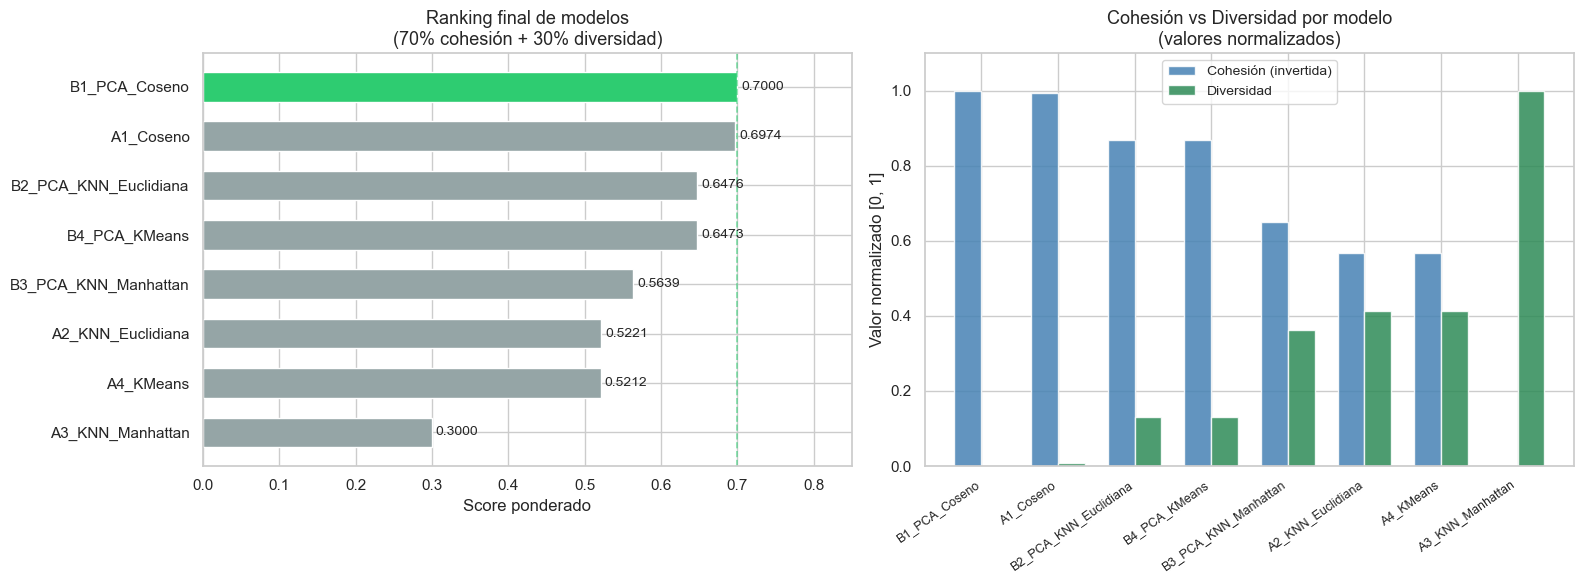

In [37]:
# Visualización: ranking de modelos por score ponderado
colores = ['#2ecc71' if i == 0 else '#95a5a6' for i in range(len(df_resultados))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Score ponderado final
bars = axes[0].barh(df_resultados['Modelo'][::-1],
                    df_resultados['Score'][::-1],
                    color=colores[::-1], edgecolor='white', height=0.6)

for bar, score in zip(bars, df_resultados['Score'][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{score:.4f}', va='center', fontsize=10)

axes[0].set_xlabel('Score ponderado', fontsize=12)
axes[0].set_title('Ranking final de modelos\n(70% cohesión + 30% diversidad)', fontsize=13)
axes[0].set_xlim(0, 0.85)
axes[0].axvline(x=df_resultados['Score'].max(), color='#2ecc71',
                linestyle='--', linewidth=1.2, alpha=0.6)

# Gráfica 2: Cohesión vs Diversidad normalizadas
x = np.arange(len(df_resultados))
width = 0.35

axes[1].bar(x - width/2, 1 - df_resultados['Cohesión_norm'],
            width, label='Cohesión (invertida)', color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, df_resultados['Diversidad_norm'],
            width, label='Diversidad', color='seagreen', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_resultados['Modelo'], rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Valor normalizado [0, 1]', fontsize=12)
axes[1].set_title('Cohesión vs Diversidad por modelo\n(valores normalizados)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('figuras/Modelos/ranking_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Interpretación y elección del modelo ganador**

El ranking final sitúa a **B1 - PCA + Similitud del Coseno** como el modelo con mayor score ponderado (0.7000), seguido de cerca por A1 - Similitud del Coseno (0.6974). Este resultado es coherente con el marco teórico del proyecto: la similitud del coseno fue identificada en el estado del arte como la métrica más adecuada para el dominio musical, al evaluar el ángulo entre vectores con independencia de su magnitud.

La aplicación del PCA sobre el espacio coseno confirma empíricamente su valor: al eliminar las dimensiones redundantes detectadas en el EDA (especialmente la correlación entre `energy` y `loudness`, r = +0.82), el espacio reducido produce vecindarios más cohesionados, reduciendo la distancia media intra-vecindario de 0.0047 a 0.0014, una mejora del 70%.

Los modelos basados en distancia euclidiana y Manhattan (con y sin PCA) obtienen scores competitivos pero inferiores, penalizados principalmente por su menor cohesión relativa. Destaca que B2 y B4 son prácticamente equivalentes (0.6476 vs 0.6473), confirmando que con K=30 el K-Means reproduce el comportamiento del KNN euclidiano tanto en el espacio original como en el reducido.

**El modelo seleccionado para la aplicación es B1 - PCA + Similitud del Coseno**, por ser el que mejor equilibra cohesión acústica y diversidad según los criterios de evaluación definidos, y por ser el resultado que mayor consistencia presenta con el fundamento teórico del sistema.

#### **Exportación del modelo ganador**

Se serializan los objetos necesarios para que la aplicación pueda cargarlos y ejecutar recomendaciones sin necesidad de reentrenar. El modelo ganador (B1) requiere dos objetos: el `pca` para transformar cualquier vector al espacio reducido, y la matriz `X_pca` completa para calcular las distancias coseno contra el catálogo. Ambos se exportan junto con los metadatos del catálogo para poder recuperar el nombre y artista de las canciones recomendadas.

In [38]:
# Exportación del modelo ganador: B1 - PCA + Similitud del Coseno
os.makedirs('models', exist_ok=True)

# PCA ya exportado en la sección 4.3, lo confirmamos
joblib.dump(pca, 'models/modelo_pca.joblib')

# Catálogo reducido: necesario para calcular distancias en la app
joblib.dump(X_pca, 'models/catalogo_pca.joblib')

# Metadatos: necesarios para mostrar título y artista de las recomendaciones
joblib.dump(df_metadata, 'models/catalogo_metadata.joblib')

print("Modelo ganador exportado correctamente:")
print("  · models/modelo_pca.joblib - transformador PCA")
print("  · models/catalogo_pca.joblib - catálogo reducido (174.582 × n_componentes)")
print("  · models/catalogo_metadata.joblib - metadatos del catálogo (título, artista)")
print(f"\nEl modelo B1_PCA_Coseno está listo para ser integrado en la aplicación.")

Modelo ganador exportado correctamente:
  · models/modelo_pca.joblib - transformador PCA
  · models/catalogo_pca.joblib - catálogo reducido (174.582 × n_componentes)
  · models/catalogo_metadata.joblib - metadatos del catálogo (título, artista)

El modelo B1_PCA_Coseno está listo para ser integrado en la aplicación.


### **4.8 Análisis de eficiencia computacional**

Este apartado mide el coste computacional de los ocho modelos comparados, cuantificando tres dimensiones:

- **Tiempo de construcción del índice** (`t_fit`): tiempo de ajuste sobre las 174.582 canciones del catálogo. Solo aplica a los modelos que requieren una fase de entrenamiento previa: KNN (A2, A3, B2, B3) y K-Means (A4, B4). La Similitud del Coseno (A1, B1) no tiene esta fase, ya que opera mediante búsqueda exhaustiva en cada consulta.
- **Tiempo de inferencia por consulta** (`t_query`): tiempo medio para recuperar las 5 recomendaciones a partir de un vector de entrada. Se mide sobre 100 consultas aleatorias y se reporta la **mediana** (más robusta frente a outliers de scheduling del SO), junto con la media y el percentil 95.
- **Uso de memoria durante el ajuste** (`mem_fit_mb`): incremento de memoria RAM (MB) provocado exclusivamente por la fase de ajuste, medido con `tracemalloc`.

> Los tiempos dependen del hardware de ejecución y deben interpretarse en términos **relativos** entre modelos.

#### **Imports adicionales y configuración**

In [39]:
import time
import tracemalloc

N_QUERIES = 100   # consultas para medir tiempo de inferencia
np.random.seed(RANDOM_STATE)
query_idx = np.random.choice(len(X), size=N_QUERIES, replace=False)
queries_orig = X[query_idx]       # (100, 24) - espacio original
queries_pca = X_pca[query_idx]    # (100, 15) - espacio reducido

os.makedirs('figuras/Eficiencia', exist_ok=True)
print(f"Muestra de consultas: {N_QUERIES} canciones")
print(f"  · Espacio original: {queries_orig.shape}")
print(f"  · Espacio reducido: {queries_pca.shape}")

Muestra de consultas: 100 canciones
  · Espacio original: (100, 24)
  · Espacio reducido: (100, 15)


#### **Funciones de medición**

In [40]:
def medir_fit(fit_fn):
    """
    Ejecuta fit_fn(), mide el tiempo de ejecución (segundos) y el
    incremento de memoria pico (MB) provocado por esa llamada.
    Devuelve: (modelo, t_fit_s, mem_pico_mb)
    """
    tracemalloc.start()
    t0 = time.perf_counter()
    modelo = fit_fn()
    t_fit = time.perf_counter() - t0
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return modelo, t_fit, pico / 1024 / 1024

In [41]:
def medir_inferencia(recomendar_fn, queries):
    """
    Llama a recomendar_fn para cada vector en queries y registra
    el tiempo individual de cada consulta (en ms).
    Devuelve: (mediana_ms, media_ms, p95_ms)
    """
    tiempos = []
    for i in range(len(queries)):
        q = queries[i].reshape(1, -1)
        t0 = time.perf_counter()
        recomendar_fn(q)
        tiempos.append((time.perf_counter() - t0) * 1000)
    t = np.array(tiempos)
    return float(np.median(t)), float(np.mean(t)), float(np.percentile(t, 95))

#### **Medición - Grupo A (espacio original, 24 dimensiones)**

In [42]:
NA = float('nan')
eficiencia = {}   # almacena (t_fit_s, mem_mb, med_ms, mean_ms, p95_ms)

# A1 - Similitud del Coseno (sin fase de ajuste)
med, mean, p95 = medir_inferencia(recomendar_coseno, queries_orig)
eficiencia['A1_Coseno'] = (NA, NA, med, mean, p95)
print(f"A1 - Coseno | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms | ajuste: N/A")

# A2 - KNN Euclidiana
_, t_fit, mem = medir_fit(
    lambda: NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='auto').fit(X)
)
med, mean, p95 = medir_inferencia(recomendar_knn_euclidean, queries_orig)
eficiencia['A2_KNN_Euclidiana'] = (t_fit, mem, med, mean, p95)
print(f"A2 - KNN Eucl. | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

# A3 - KNN Manhattan
_, t_fit, mem = medir_fit(
    lambda: NearestNeighbors(n_neighbors=6, metric='manhattan', algorithm='auto').fit(X)
)
med, mean, p95 = medir_inferencia(recomendar_knn_manhattan, queries_orig)
eficiencia['A3_KNN_Manhattan'] = (t_fit, mem, med, mean, p95)
print(f"A3 - KNN Manh. | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

# A4 - K-Means
_, t_fit, mem = medir_fit(
    lambda: KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init='auto').fit(X)
)
med, mean, p95 = medir_inferencia(recomendar_kmeans, queries_orig)
eficiencia['A4_KMeans'] = (t_fit, mem, med, mean, p95)
print(f"A4 - K-Means   | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

A1 - Coseno | inferencia: mediana=32.60 ms, p95=37.80 ms | ajuste: N/A
A2 - KNN Eucl. | ajuste: 0.015 s, 32.11 MB | inferencia: mediana=3.31 ms, p95=4.05 ms
A3 - KNN Manh. | ajuste: 0.015 s, 32.11 MB | inferencia: mediana=1.46 ms, p95=1.87 ms
A4 - K-Means   | ajuste: 1.108 s, 64.00 MB | inferencia: mediana=2.82 ms, p95=4.61 ms


#### **Medición - Grupo B (espacio reducido PCA, 15 dimensiones)**

In [43]:
# B1 - PCA + Similitud del Coseno (sin fase de ajuste)
med, mean, p95 = medir_inferencia(recomendar_coseno_pca, queries_pca)
eficiencia['B1_PCA_Coseno'] = (NA, NA, med, mean, p95)
print(f"B1 - PCA+Coseno    | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms | ajuste: N/A")

# B2 - PCA + KNN Euclidiana
_, t_fit, mem = medir_fit(
    lambda: NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='auto').fit(X_pca)
)
med, mean, p95 = medir_inferencia(recomendar_knn_euclidean_pca, queries_pca)
eficiencia['B2_PCA_KNN_Euclidiana'] = (t_fit, mem, med, mean, p95)
print(f"B2 - PCA+KNN Eucl. | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

# B3 - PCA + KNN Manhattan
_, t_fit, mem = medir_fit(
    lambda: NearestNeighbors(n_neighbors=6, metric='manhattan', algorithm='auto').fit(X_pca)
)
med, mean, p95 = medir_inferencia(recomendar_knn_manhattan_pca, queries_pca)
eficiencia['B3_PCA_KNN_Manhattan'] = (t_fit, mem, med, mean, p95)
print(f"B3 - PCA+KNN Manh. | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

# B4 - PCA + K-Means
_, t_fit, mem = medir_fit(
    lambda: KMeans(n_clusters=K_OPTIMO, random_state=RANDOM_STATE, n_init='auto').fit(X_pca)
)
med, mean, p95 = medir_inferencia(recomendar_kmeans_pca, queries_pca)
eficiencia['B4_PCA_KMeans'] = (t_fit, mem, med, mean, p95)
print(f"B4 - PCA+K-Means   | ajuste: {t_fit:.3f} s, {mem:.2f} MB | inferencia: mediana={med:.2f} ms, p95={p95:.2f} ms")

B1 - PCA+Coseno    | inferencia: mediana=27.52 ms, p95=30.14 ms | ajuste: N/A
B2 - PCA+KNN Eucl. | ajuste: 0.729 s, 3.60 MB | inferencia: mediana=0.67 ms, p95=0.97 ms
B3 - PCA+KNN Manh. | ajuste: 0.704 s, 3.60 MB | inferencia: mediana=0.49 ms, p95=0.79 ms
B4 - PCA+K-Means   | ajuste: 1.007 s, 42.78 MB | inferencia: mediana=1.79 ms, p95=3.01 ms


#### **Tabla resumen de eficiencia**

In [44]:
df_eficiencia = pd.DataFrame(
    [(k, *v) for k, v in eficiencia.items()],
    columns=['Modelo', 't_fit_s', 'mem_fit_mb',
             'inferencia_mediana_ms', 'inferencia_media_ms', 'inferencia_p95_ms']
)

print("Tabla de eficiencia computacional (NaN = sin fase de ajuste):\n")
df_eficiencia.style\
    .format({'t_fit_s': '{:.3f}', 'mem_fit_mb': '{:.2f}',
             'inferencia_mediana_ms': '{:.2f}',
             'inferencia_media_ms': '{:.2f}',
             'inferencia_p95_ms': '{:.2f}'}, na_rep='N/A')\
    .background_gradient(subset=['inferencia_mediana_ms'], cmap='RdYlGn_r')

Tabla de eficiencia computacional (NaN = sin fase de ajuste):



,Modelo,t_fit_s,mem_fit_mb,inferencia_mediana_ms,inferencia_media_ms,inferencia_p95_ms
0,A1_Coseno,N/A,N/A,32.60,33.37,37.80
1,A2_KNN_Euclidiana,0.015,32.11,3.31,3.38,4.05
2,A3_KNN_Manhattan,0.015,32.11,1.46,1.50,1.87
3,A4_KMeans,1.108,64.00,2.82,3.12,4.61
4,B1_PCA_Coseno,N/A,N/A,27.52,27.92,30.14
5,B2_PCA_KNN_Euclidiana,0.729,3.60,0.67,0.69,0.97
6,B3_PCA_KNN_Manhattan,0.704,3.60,0.49,0.54,0.79
7,B4_PCA_KMeans,1.007,42.78,1.79,1.99,3.01


In [45]:
# Verificación de los algoritmos internos seleccionados tras el ajuste

# KNN: el atributo _fit_method expone qué estructura de índice eligió scikit-learn con algorithm='auto' una vez ajustado el modelo.
print("Estructura de índice seleccionada por scikit-learn (algorithm='auto'):")
print(f"  A2 - KNN Euclidiana (24 dims): {knn_euclidean._fit_method}")
print(f"  A3 - KNN Manhattan  (24 dims): {knn_manhattan._fit_method}")
print(f"  B2 - KNN Euclidiana (15 dims): {knn_euclidean_pca._fit_method}")
print(f"  B3 - KNN Manhattan  (15 dims): {knn_manhattan_pca._fit_method}")

# K-Means: no usa estructuras de índice, pero n_iter_ e n_init permiten cuantificar el coste real del ajuste.
print(f"\nDetalle del ajuste de K-Means:")
print(f"  A4 - K-Means (24 dims): {kmeans.n_iter_} iteraciones, "
      f"n_init={kmeans.n_init}, "
      f"init={kmeans.init}")
print(f"  B4 - K-Means (15 dims): {kmeans_pca.n_iter_} iteraciones, "
      f"n_init={kmeans_pca.n_init}, "
      f"init={kmeans_pca.init}")

Estructura de índice seleccionada por scikit-learn (algorithm='auto'):
  A2 - KNN Euclidiana (24 dims): brute
  A3 - KNN Manhattan  (24 dims): brute
  B2 - KNN Euclidiana (15 dims): kd_tree
  B3 - KNN Manhattan  (15 dims): kd_tree

Detalle del ajuste de K-Means:
  A4 - K-Means (24 dims): 24 iteraciones, n_init=auto, init=k-means++
  B4 - K-Means (15 dims): 23 iteraciones, n_init=auto, init=k-means++


In [46]:
import sklearn
print(sklearn.__version__)

1.8.0


> **Nota sobre `n_init='auto'`:** según la documentación oficial de scikit-learn 1.8.0, 
> `n_init='auto'` con `init='k-means++'` equivale a `n_init=1` (una única inicialización), 
> ya que `k-means++` genera centroides iniciales de calidad que no requieren múltiples reintentos.
> Fuente: [sklearn.cluster.KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

#### **Visualización de resultados**

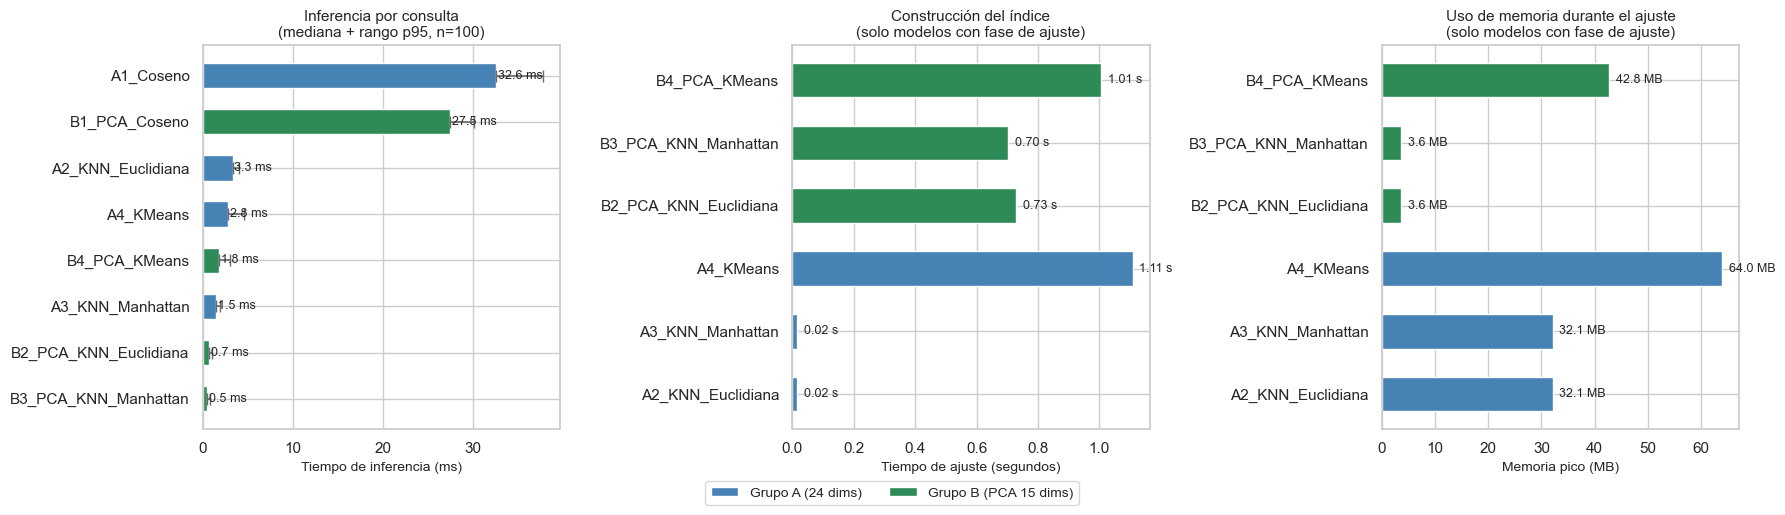

In [47]:
colores_grupo = {'A': 'steelblue', 'B': 'seagreen'}
grupos = ['A' if m.startswith('A') else 'B' for m in df_eficiencia['Modelo']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Tiempo de inferencia (todos los modelos)
orden = df_eficiencia.sort_values('inferencia_mediana_ms', ascending=True)
cols  = [colores_grupo['A' if m.startswith('A') else 'B'] for m in orden['Modelo']]

bars = axes[0].barh(orden['Modelo'], orden['inferencia_mediana_ms'],
                    color=cols, edgecolor='white', height=0.55)
xerr_high = (orden['inferencia_p95_ms'] - orden['inferencia_mediana_ms']).values
axes[0].errorbar(orden['inferencia_mediana_ms'], orden['Modelo'],
                 xerr=[np.zeros(len(orden)), xerr_high],
                 fmt='none', color='dimgray', capsize=4, linewidth=1.2)
for bar, v in zip(bars, orden['inferencia_mediana_ms']):
    axes[0].text(bar.get_width() + max(xerr_high)*0.04,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:.1f} ms', va='center', fontsize=9)
axes[0].set_xlabel('Tiempo de inferencia (ms)', fontsize=10)
axes[0].set_title(f'Inferencia por consulta\n(mediana + rango p95, n={N_QUERIES})', fontsize=11)

# Gráfica 2: Tiempo de ajuste (modelos con fit)
df_fit = df_eficiencia.dropna(subset=['t_fit_s'])
cols2  = [colores_grupo['A' if m.startswith('A') else 'B'] for m in df_fit['Modelo']]
bars2  = axes[1].barh(df_fit['Modelo'], df_fit['t_fit_s'],
                      color=cols2, edgecolor='white', height=0.55)
for bar, v in zip(bars2, df_fit['t_fit_s']):
    axes[1].text(bar.get_width() + df_fit['t_fit_s'].max()*0.02,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:.2f} s', va='center', fontsize=9)
axes[1].set_xlabel('Tiempo de ajuste (segundos)', fontsize=10)
axes[1].set_title('Construcción del índice\n(solo modelos con fase de ajuste)', fontsize=11)

# Gráfica 3: Uso de memoria (modelos con fit)
bars3 = axes[2].barh(df_fit['Modelo'], df_fit['mem_fit_mb'],
                     color=cols2, edgecolor='white', height=0.55)
for bar, v in zip(bars3, df_fit['mem_fit_mb']):
    axes[2].text(bar.get_width() + df_fit['mem_fit_mb'].max()*0.02,
                 bar.get_y() + bar.get_height()/2,
                 f'{v:.1f} MB', va='center', fontsize=9)
axes[2].set_xlabel('Memoria pico (MB)', fontsize=10)
axes[2].set_title('Uso de memoria durante el ajuste\n(solo modelos con fase de ajuste)', fontsize=11)

# Leyenda común
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='steelblue', label='Grupo A (24 dims)'),
                Patch(facecolor='seagreen',  label='Grupo B (PCA 15 dims)')]
fig.legend(handles=legend_elems, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('figuras/Eficiencia/eficiencia_computacional.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Impacto del PCA en la eficiencia: Grupo A vs. Grupo B**

Reducción relativa (%) en cada dimensión de coste al pasar del espacio original (24 dims) al espacio reducido por PCA (15 dims), para cada algoritmo.

In [48]:
pares = [
    ('Coseno',    'A1_Coseno',        'B1_PCA_Coseno'),
    ('KNN Eucl.', 'A2_KNN_Euclidiana','B2_PCA_KNN_Euclidiana'),
    ('KNN Manh.', 'A3_KNN_Manhattan', 'B3_PCA_KNN_Manhattan'),
    ('K-Means',   'A4_KMeans',        'B4_PCA_KMeans'),
]
idx = df_eficiencia.set_index('Modelo')

def reduccion(a, b):
    return (a - b) / a * 100 if (pd.notna(a) and pd.notna(b) and a != 0) else float('nan')

filas = []
for nombre, a_id, b_id in pares:
    filas.append({
        'Algoritmo':      nombre,
        'Inf A (ms)':     idx.loc[a_id, 'inferencia_mediana_ms'],
        'Inf B (ms)':     idx.loc[b_id, 'inferencia_mediana_ms'],
        'Δ Inferencia':   reduccion(idx.loc[a_id, 'inferencia_mediana_ms'],
                                    idx.loc[b_id, 'inferencia_mediana_ms']),
        'Fit A (s)':      idx.loc[a_id, 't_fit_s'],
        'Fit B (s)':      idx.loc[b_id, 't_fit_s'],
        'Δ Ajuste':       reduccion(idx.loc[a_id, 't_fit_s'], idx.loc[b_id, 't_fit_s']),
        'Mem A (MB)':     idx.loc[a_id, 'mem_fit_mb'],
        'Mem B (MB)':     idx.loc[b_id, 'mem_fit_mb'],
        'Δ Memoria':      reduccion(idx.loc[a_id, 'mem_fit_mb'], idx.loc[b_id, 'mem_fit_mb']),
    })

df_impacto = pd.DataFrame(filas)
print("Reducción relativa al aplicar PCA (valores positivos = mejora):\n")
df_impacto.style\
    .format({'Inf A (ms)': '{:.2f}', 'Inf B (ms)': '{:.2f}', 'Δ Inferencia': '{:.1f}%',
             'Fit A (s)':  '{:.3f}', 'Fit B (s)':  '{:.3f}', 'Δ Ajuste':     '{:.1f}%',
             'Mem A (MB)': '{:.2f}', 'Mem B (MB)': '{:.2f}', 'Δ Memoria':    '{:.1f}%'},
            na_rep='N/A')\
    .background_gradient(subset=['Δ Inferencia'], cmap='RdYlGn')

Reducción relativa al aplicar PCA (valores positivos = mejora):



,Algoritmo,Inf A (ms),Inf B (ms),Δ Inferencia,Fit A (s),Fit B (s),Δ Ajuste,Mem A (MB),Mem B (MB),Δ Memoria
0,Coseno,32.60,27.52,15.6%,N/A,N/A,N/A,N/A,N/A,N/A
1,KNN Eucl.,3.31,0.67,79.8%,0.015,0.729,-4726.3%,32.11,3.60,88.8%
2,KNN Manh.,1.46,0.49,66.8%,0.015,0.704,-4541.5%,32.11,3.60,88.8%
3,K-Means,2.82,1.79,36.3%,1.108,1.007,9.2%,64.00,42.78,33.2%
